# **Machine Learning Project: Fetal Health Classification**

Data: https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification

Phase 1: Short Data Summary

1.   Dataset name - Fetal Health Classification Dataset
2.   Source link -  https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification
3.   Problem description - The dataset helps us to predict the health condition of a fetus related to Cardiotocography (CTG) measurements. These measurements monitor the fetal heart rate and uterine contractions during pregnancy. Machine learning models can analyze these medical indicators and classify the fetal condition into different health categories.
4.   Target variable - Fetal health
5.   Number of rows and columns - 2126,22

Phase 2 — Problem Definition

The objective of the whole problem is to develop a machine model which will help us to predict the heath condtions of a fetus related to Cardiotocography (CTG) measurenments. The dataset contains various numerical features like fetal heart rate patterns, uterine contractions, and other that will our model to predict more precisely.
The model aims to classify the fetal health among Three categories - Normal, Suspect and Pathological. Our target variable is "Fetal_health". Early detection of fetal condition through our models help us to understand the complexity or to know the condition of both fetal and mother.
Machine learning techniques helps us to find patterns, analyse complex data that may indicate early symptoms and help us to take early precautions.

In [314]:
# from google.colab import drive
# drive.mount('/content/drive')

## Libraries

In [315]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [316]:
df = pd.read_csv('data.csv')

In [317]:
df.head(10)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.000,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.000,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.000,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
5,134.0,0.001,0.0,0.010,0.009,0.0,0.002,26.0,5.9,0.0,0.0,150.0,50.0,200.0,5.0,3.0,76.0,107.0,107.0,170.0,0.0,3.0
6,134.0,0.001,0.0,0.013,0.008,0.0,0.003,29.0,6.3,0.0,0.0,150.0,50.0,200.0,6.0,3.0,71.0,107.0,106.0,215.0,0.0,3.0
7,122.0,0.000,0.0,0.000,0.000,0.0,0.000,83.0,0.5,6.0,15.6,68.0,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
8,122.0,0.000,0.0,0.002,0.000,0.0,0.000,84.0,0.5,5.0,13.6,68.0,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
9,122.0,0.000,0.0,0.003,0.000,0.0,0.000,86.0,0.3,6.0,10.6,68.0,62.0,130.0,1.0,0.0,122.0,122.0,123.0,1.0,1.0,3.0


## Data Statistics

Find the methods to understand the data and implement by your own. Each and every code of your's, I must be able to see what was the input and output of coding line.

In [318]:
df.shape

(2126, 22)

In [319]:
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,8.187629,70.445908,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,5.628247,38.955693,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,3.000000,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,4.600000,37.000000,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,7.400000,67.500000,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,10.800000,100.000000,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,50.700000,180.000000,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [320]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [321]:
df.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [322]:
print(df.dtypes.value_counts())

float64    22
Name: count, dtype: int64


In [323]:
target_counts = df['fetal_health'].value_counts()
target_labels = {1: 'Normal', 2: 'Suspect', 3: 'Pathological'}

In [324]:
target_counts

fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

In [325]:
target_labels

{1: 'Normal', 2: 'Suspect', 3: 'Pathological'}

target_labels is created to indicate the condition of fetal in which 1 indicates the fetal should be normal, 2 indicates that the fetal is suspected to be get damage or thier condition may become critical in future and 3 indicates that the condition of fetal is critical.

## Exploratory Data Analysis

In [326]:

def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

print("Outlier Analysis (IQR Method):")
print("=" * 70)

outlier_summary = [
    {
        'Feature': col,
        'Outlier Count': count,
        'Percentage': f'{(count / len(df)) * 100:.2f}%'
    }
    for col in df.columns[:-1]
    for count, lower, upper in [detect_outliers_iqr(df[col])]
]

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

Outlier Analysis (IQR Method):
                                               Feature  Outlier Count Percentage
                                        baseline value              0      0.00%
                                         accelerations             14      0.66%
                                        fetal_movement            307     14.44%
                                  uterine_contractions              1      0.05%
                                   light_decelerations            150      7.06%
                                  severe_decelerations              7      0.33%
                              prolongued_decelerations            178      8.37%
                       abnormal_short_term_variability              0      0.00%
                  mean_value_of_short_term_variability             70      3.29%
percentage_of_time_with_abnormal_long_term_variability            309     14.53%
                   mean_value_of_long_term_variability             71      3.3

Outliers are those values which is odd from other values or can be say way more higher or lower than other values.

when we should remove outliers:-
-> when the value is unexpected to achieve for example: negative heart rate.
-> when it affect data and create imbalance in data.
-> reduce accuracy of model.
In this fetal dataset we can not remove the outliers directly as this dataset is related to healthcare every single information is important and outliers works as main point.
for example: someone heart rate is very high than other than thier is more chance that the fetal comes under pathological condition.

Find the 10 questions that can be answered using the plots.

Create a plan first.

Questions:

1. What is the distribution of fetal health categories in the dataset?

This Chart(pie,bar) shows how many samples belong to the different categories of fetal health data(normal, suspect, pathological).
Tells us if the data is balanced or not. Pie charts gives us the percentage wise distribution among the fetal_health categories

Text(0.5, -0.1, 'Fetal Health Distribution')

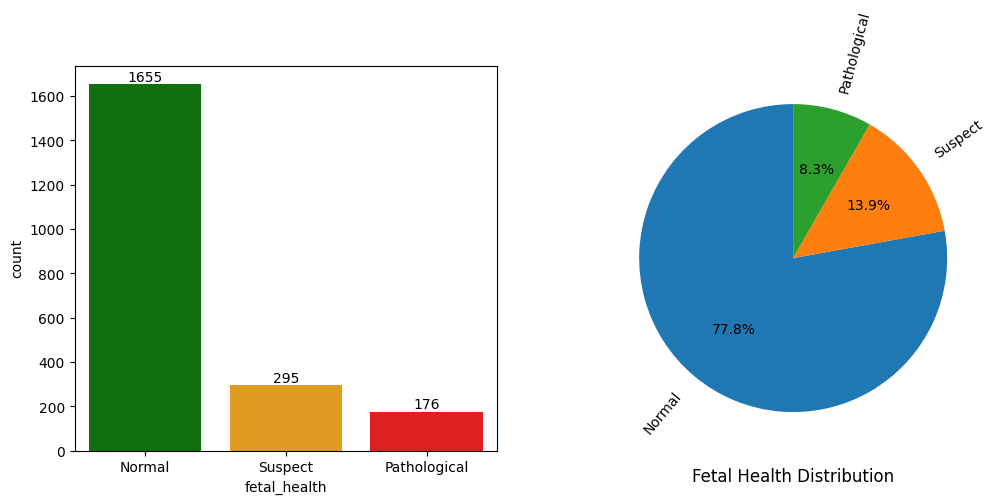

In [327]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
k=sns.countplot(x="fetal_health",data=df,palette=["green", "orange", "red"],ax=axes[0])
for contain in k.containers:
    k.bar_label(contain)
axes[0].set_xticks([0,1,2])
axes[0].set_xticklabels(["Normal","Suspect","Pathological"])
j=axes[1].pie(df['fetal_health'].value_counts(),labels=["Normal","Suspect","Pathological"],rotatelabels=50,startangle=90,autopct="%1.1f%%")
axes[1].set_title("Fetal Health Distribution",y=-0.1)

the above charts show the fetal health distribution, according to these charts 176 fetals i.e. 8.3% of total comes under pathological condition,where 77.8% fetal health is normal and 13.9% fetal is comes under suspected condition.Which show that the data is imbalance as most of the data lies under normal condition.

2. How is the baseline fetal heart rate distributed?

Tells us about the basline fetal heart reate feature and shows us some outliners.

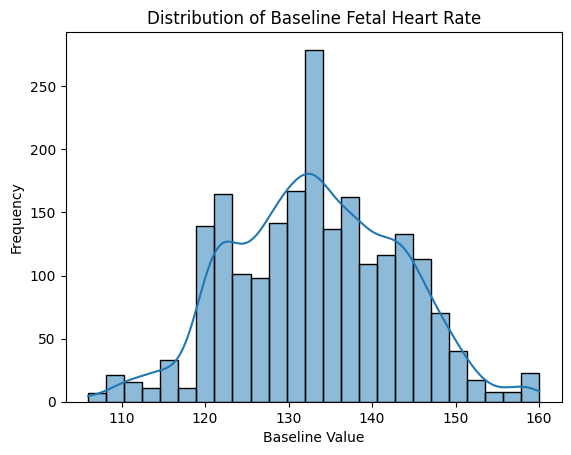

In [328]:
sns.histplot(df['baseline value'], kde=True)
plt.title("Distribution of Baseline Fetal Heart Rate")
plt.xlabel("Baseline Value")
plt.ylabel("Frequency")
plt.show()

As we can see most value comes in middle part hence it is a normal distribution.
This graph shows the mode value of 130-135 because the frequency is maximum in that region.
The baseline value is between 105-160.
As the data is normally distributed,it is good for analysis.

3. How is Correlation Heatmap helps us to understand the all features?

This heatmap visualizes the correlation between all features in the dataset. Each cell represents the strength and direction of the relationship between two variables, where values close to +1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values near 0 indicate little or no correlation. So, by analyzing the heatmap we can clearly spot the features which are strongly related to target variable "Fetal_health"

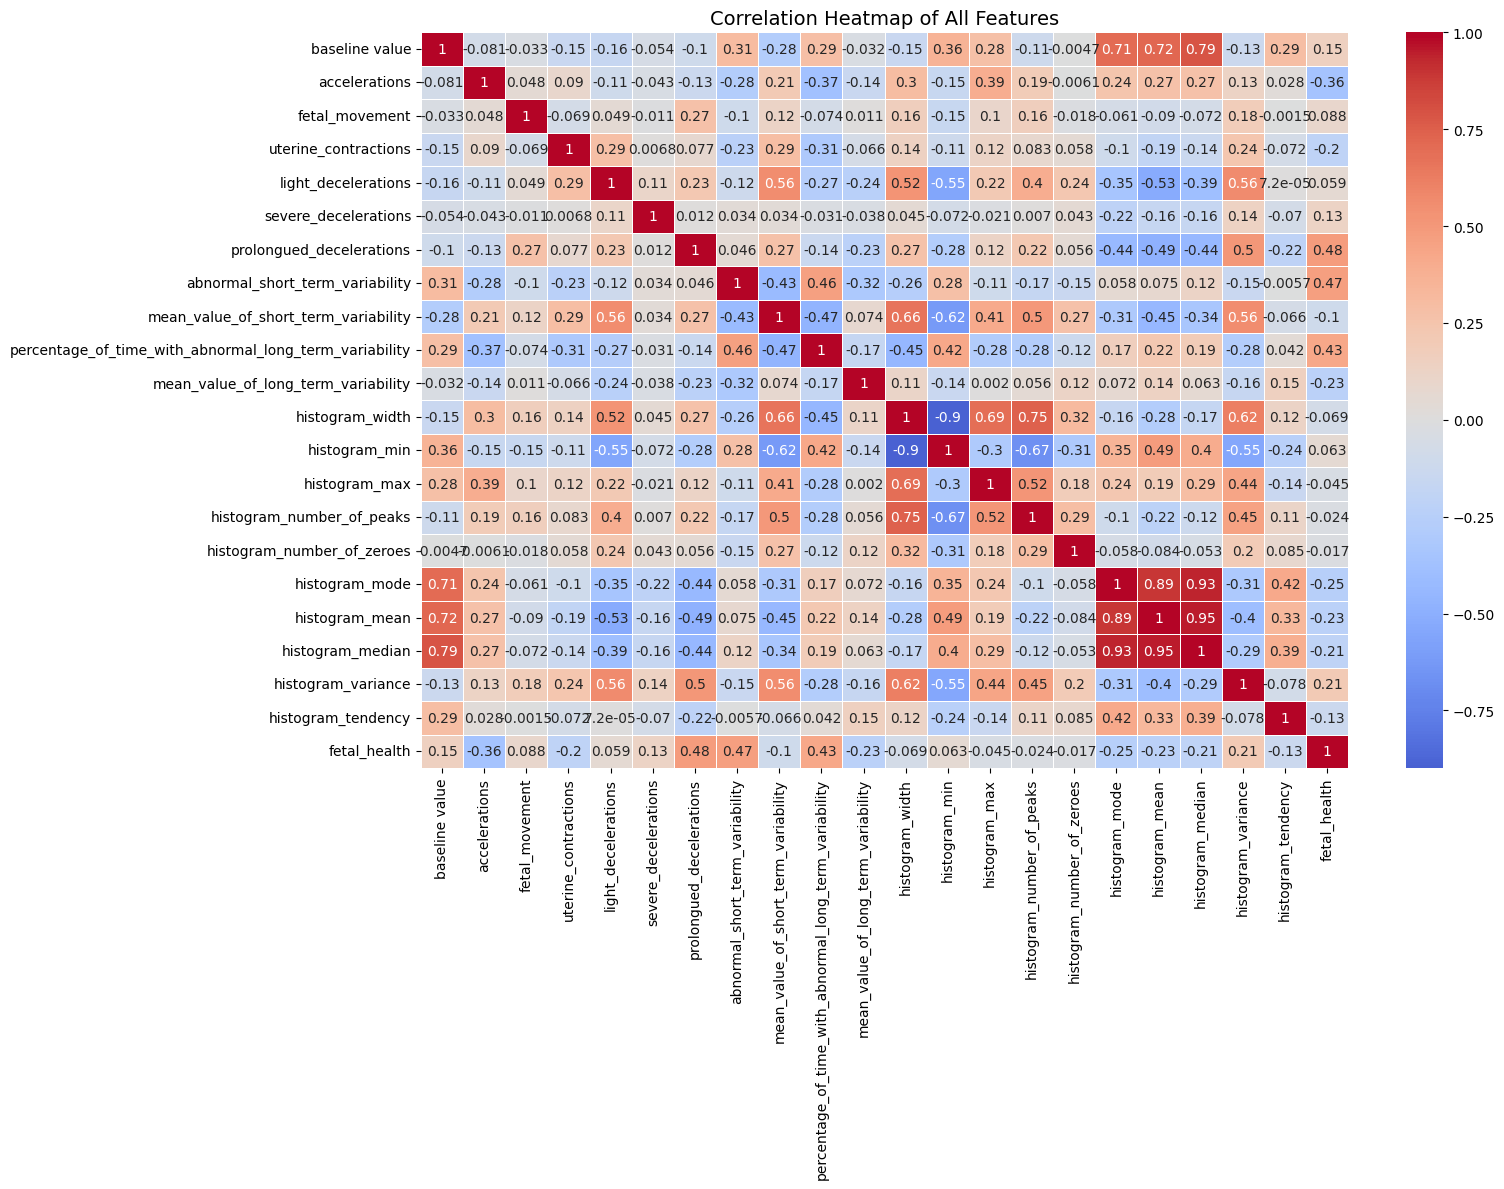

In [329]:

plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
           linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=14)
plt.tight_layout()
plt.show()

As we can see that hitogram_mean,histogram_mode and histogram_median are highly correlated to each other so we can choose any one from these three in our analysis and reduce the dimension of dataset, which helps to run code faster.

In [330]:
df=df.drop(columns=["histogram_mean","histogram_mode"])

4. What is the distribution of key features indiviudally?

By the hist plot we can clearly see the distribution among different features individually.

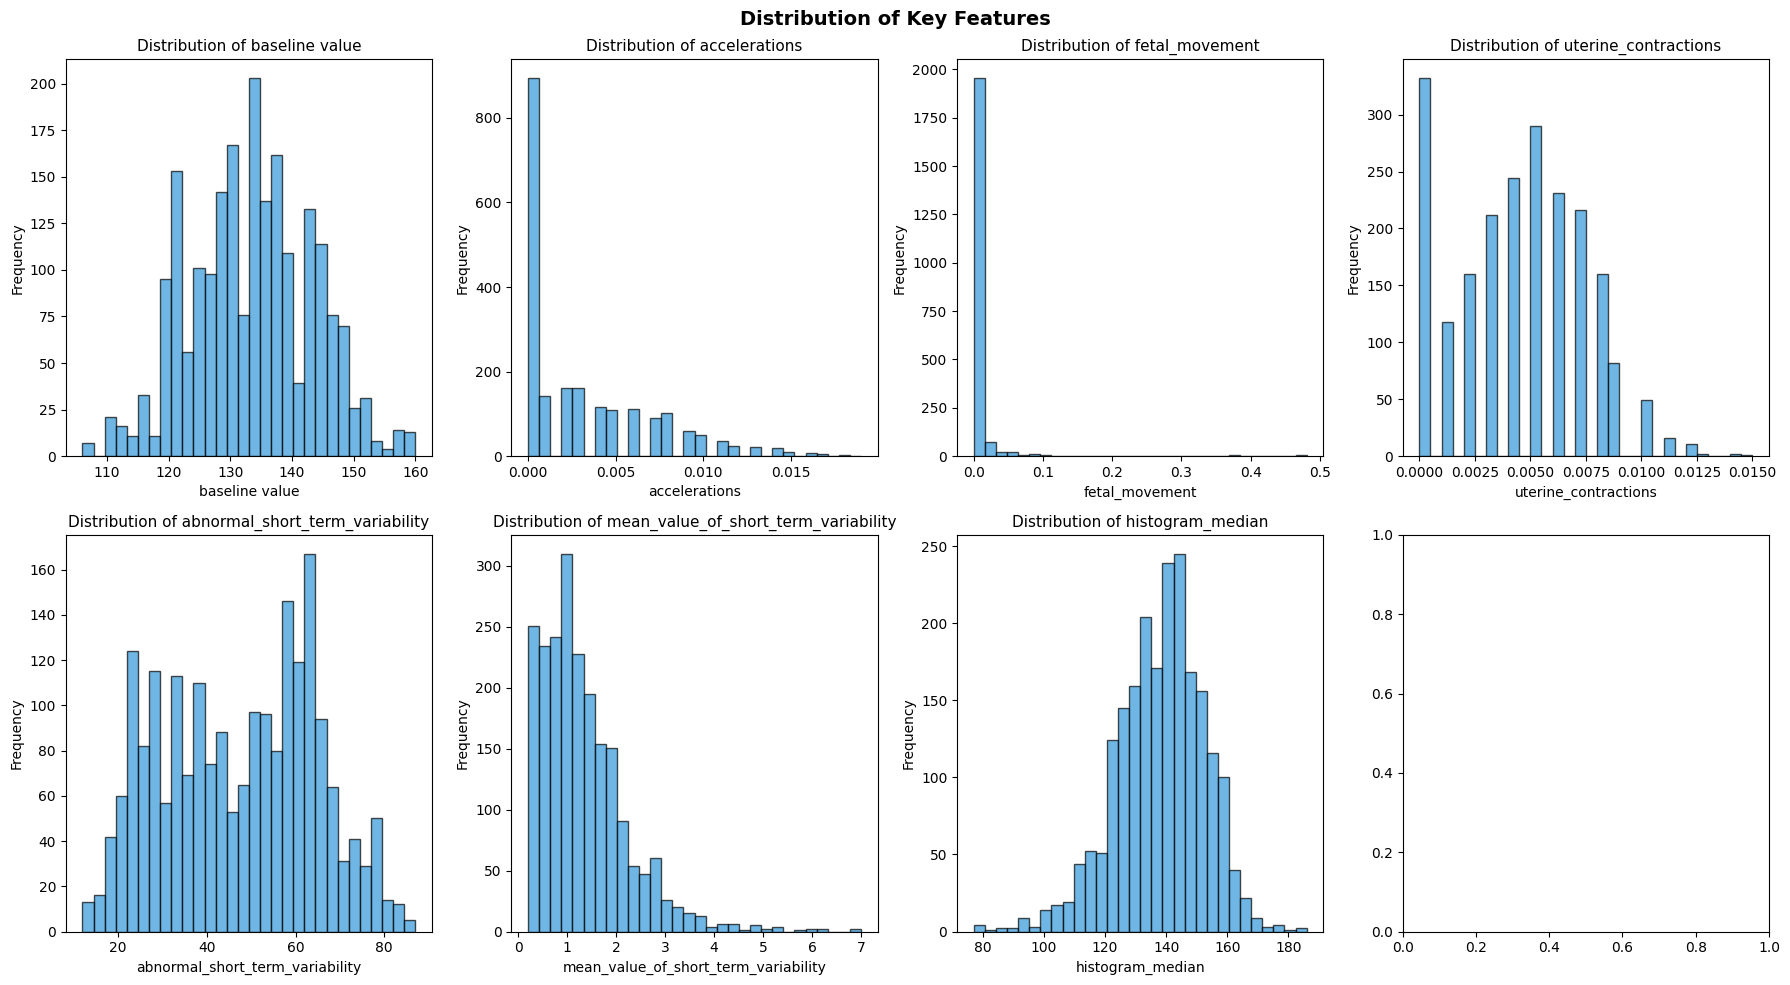

In [331]:
key_features = ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions',
                'abnormal_short_term_variability', 'mean_value_of_short_term_variability',
                 'histogram_median']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    axes[i].hist(df[feature], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {feature}', fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

these graphs shows that the data skew as the data is not normally distributed so we can focus this point in our model selection step.

5. How do key features vary across different fetal health conditions?

This visualization helps in feature importance analysis and understanding class-wise differences, which is essential for building accurate machine learning models.

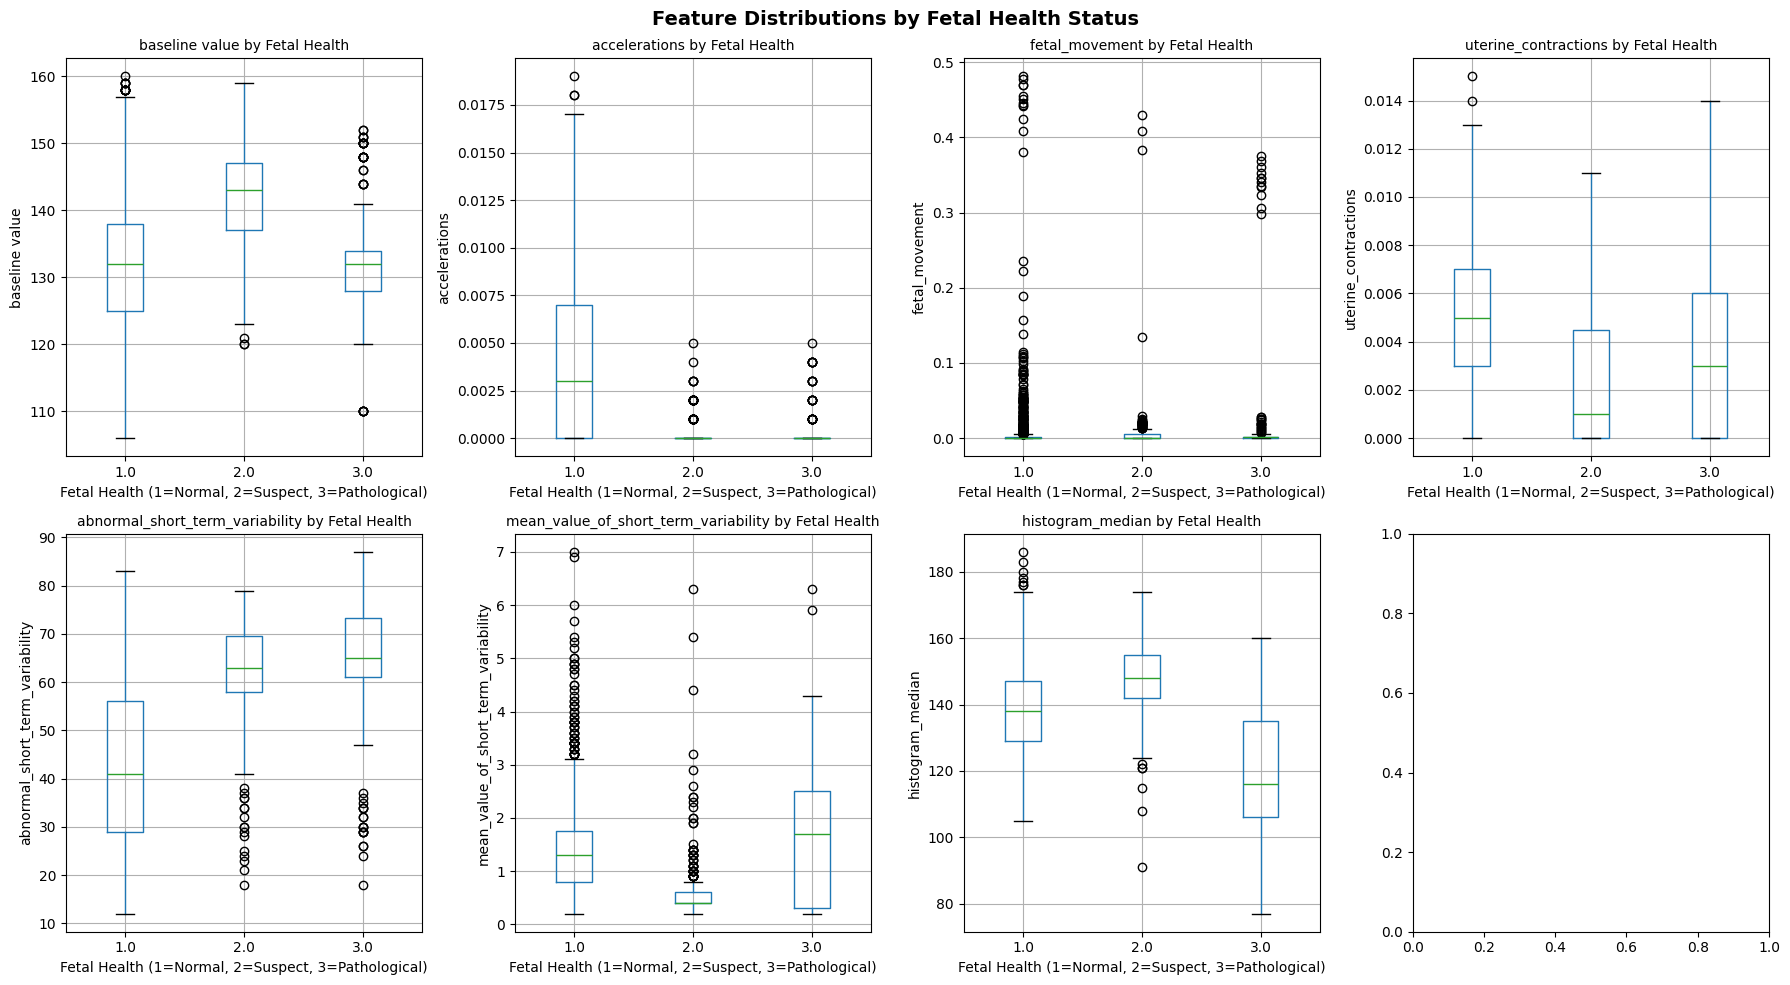

In [332]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    df.boxplot(column=feature, by='fetal_health', ax=axes[i])
    axes[i].set_title(f'{feature} by Fetal Health', fontsize=10)
    axes[i].set_xlabel('Fetal Health (1=Normal, 2=Suspect, 3=Pathological)')
    axes[i].set_ylabel(feature)

plt.suptitle('Feature Distributions by Fetal Health Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### The insights of these graphs are:-
moderate predictors:- baseline_value,uterine_contaction,mean_value_of_term_variability  (overlapping between classes occured)

weak predictors    :- fetal_movement    (all the values are close to zero, cannot differentiate fetal health)

strong predictors  :- acceleration,abnormal_short_term_variability,histogram_median     (seperation between classes is clear, no overlapping or less overlapping occured)

In [333]:
df['fetal_movement_binary'] = df['fetal_movement'].apply(lambda x: 0 if x==0 else 1)

In [334]:
df=df.drop(columns=["fetal_movement"])

As we saw in boxplot that fetal_movement is weak predictor when it is alone but when it is with other attributes then it should be helpful, it only tell the movement in fetal,could not differentiate between suspect and pathological properly so we convert this column into binary column which only tells us to identify whether the movement occurs or not.

### Preprocessing Decisions Summary

| Decision | Reason |
|----------|--------|
| **No missing value handling needed** | Dataset has no missing values |
| **No categorical encoding needed** | All features are numerical |
| **Applied StandardScaler** | Ensures all features have mean=0 and std=1, important for SVM and Logistic Regression |
| **Used stratified split** | Maintains class proportions in train/test sets |
| **Kept all features** | All features are relevant medical measurements; no dimensionality reduction needed initially |

In [335]:
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (2126, 19)
Target shape: (2126,)


t_SNE+clustering

###Train Test split


In [336]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset Split:")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in testing set:")
print(y_test.value_counts())

Dataset Split:
Training set: 1700 samples (80.0%)
Testing set: 426 samples (20.0%)

Class distribution in training set:
fetal_health
1.0    1323
2.0     236
3.0     141
Name: count, dtype: int64

Class distribution in testing set:
fetal_health
1.0    332
2.0     59
3.0     35
Name: count, dtype: int64


##Model Selection

We will use three algorithms:
- Logistic Regression
- Random Forest
- Support Vector Machine

In [337]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

In [338]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=23)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [339]:
# from sklearn.svm import SVC

# svm = SVC()
# svm.fit(X_train, y_train)
# pred_svm = svm.predict(X_test)
from sklearn.ensemble import ExtraTreesClassifier

model_et = ExtraTreesClassifier(n_estimators=100, random_state=42)
model_et.fit(X_train, y_train)
y_pred_et = model_et.predict(X_test)

## Phase 6 – Model Evaluation

In [340]:
# Logistic Regression Evaluation
print('Logistic Regression Accuracy:', accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 0.8826291079812206
[[313  16   3]
 [ 18  39   2]
 [  2   9  24]]
              precision    recall  f1-score   support

         1.0       0.94      0.94      0.94       332
         2.0       0.61      0.66      0.63        59
         3.0       0.83      0.69      0.75        35

    accuracy                           0.88       426
   macro avg       0.79      0.76      0.78       426
weighted avg       0.88      0.88      0.88       426



In [341]:
# Random Forest Evaluation
print('Random Forest Accuracy:', accuracy_score(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Random Forest Accuracy: 0.9366197183098591
[[328   3   1]
 [ 15  41   3]
 [  2   3  30]]
              precision    recall  f1-score   support

         1.0       0.95      0.99      0.97       332
         2.0       0.87      0.69      0.77        59
         3.0       0.88      0.86      0.87        35

    accuracy                           0.94       426
   macro avg       0.90      0.85      0.87       426
weighted avg       0.93      0.94      0.93       426



In [342]:
# ExtraTrees Evaluation
print('ExtraTrees Accuracy:', accuracy_score(y_test, y_pred_et))
print(confusion_matrix(y_test, y_pred_et))
print(classification_report(y_test,y_pred_et))

ExtraTrees Accuracy: 0.9272300469483568
[[326   5   1]
 [ 13  43   3]
 [  2   7  26]]
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       332
         2.0       0.78      0.73      0.75        59
         3.0       0.87      0.74      0.80        35

    accuracy                           0.93       426
   macro avg       0.87      0.82      0.84       426
weighted avg       0.92      0.93      0.93       426



<Axes: >

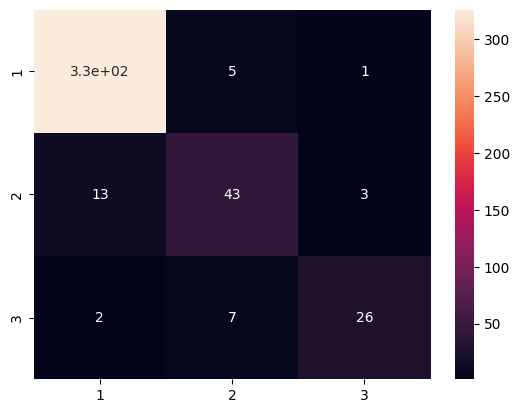

In [343]:
sns.heatmap(confusion_matrix(y_test, y_pred_et), annot=True,xticklabels=target_labels,yticklabels=target_labels)


## Model Comparison


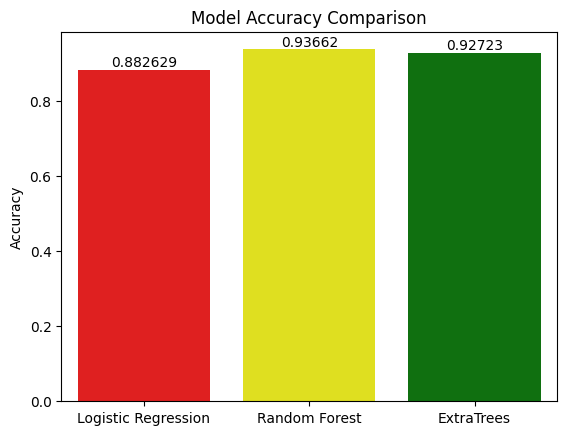

In [344]:
models = ['Logistic Regression','Random Forest','ExtraTrees']
colors=["red","yellow","green"]
accuracies = [
    accuracy_score(y_test, pred_lr),
    accuracy_score(y_test, pred_rf),
    accuracy_score(y_test, y_pred_et)
]
k=sns.barplot(accuracies,palette=colors)
for i in k.containers:
    k.bar_label(i)
plt.xticks([0,1,2],models)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

So the upper barplot tells the accuracy of three different model which we applied, by this plot we can  understand that the accuracy of trees model is high then other.random forest gives the highest accuracy 93.66% and extratrees gives 92.72% accuracy and logistic regression gives an accuracy of 88.26%

In [345]:
import pickle
with open("rf.pkl", "wb") as model_file:
    pickle.dump(rf,model_file)


In [346]:
with open("rf.pkl", "rb") as model_file:
    loaded_rf_model = pickle.load(model_file)


In [347]:
loaded_rf_model.predict(X_test)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1.,
       3., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 3., 2., 1., 1., 1.,
       1., 1., 1., 1., 3., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 3., 1.,
       1., 1., 1., 1., 1., 2., 1., 2., 1., 1., 1., 1., 2., 2., 3., 1., 1.,
       1., 1., 2., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1.,
       2., 2., 1., 1., 1., 1., 2., 2., 1., 1., 3., 1., 1., 1., 1., 1., 1.,
       2., 2., 1., 1., 1., 1., 2., 1., 1., 1., 2., 2., 1., 1., 1., 1., 2.,
       1., 1., 1., 1., 1., 1., 3., 3., 3., 2., 3., 1., 1., 3., 1., 1., 1.,
       1., 3., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 1.,
       1., 2., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 2., 2., 1., 1., 1.,
       1., 1., 1., 1., 1., 3., 2., 1., 3., 2., 2., 1., 1., 1., 1., 1., 2.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2.,
       1., 2., 1., 1., 1.